# Student Social Media Addiction - Data Analysis & Classification

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/Students Social Media Addiction.csv")

# Encode categorical columns
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})

# Drop missing values
df.dropna(inplace=True)

# Relabel Addicted_Score to start from 1
df['Addicted_Score'] = df['Addicted_Score'] - df['Addicted_Score'].min() + 1


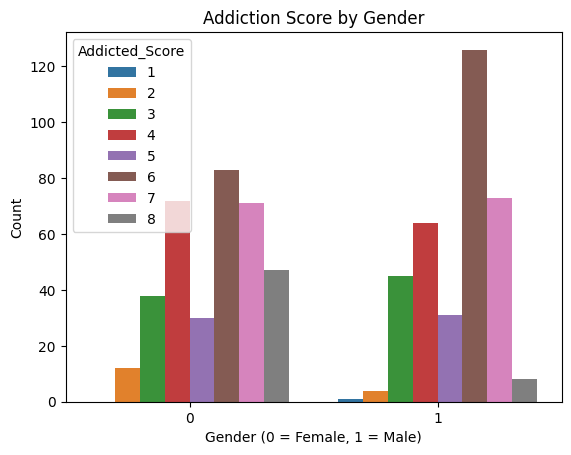

In [2]:

sns.countplot(data=df, x='Gender', hue='Addicted_Score')
plt.title("Addiction Score by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()


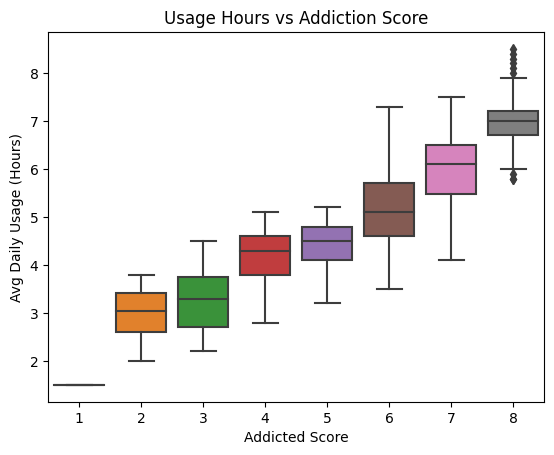

In [3]:

sns.boxplot(data=df, x='Addicted_Score', y='Avg_Daily_Usage_Hours')
plt.title("Usage Hours vs Addiction Score")
plt.xlabel("Addicted Score")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


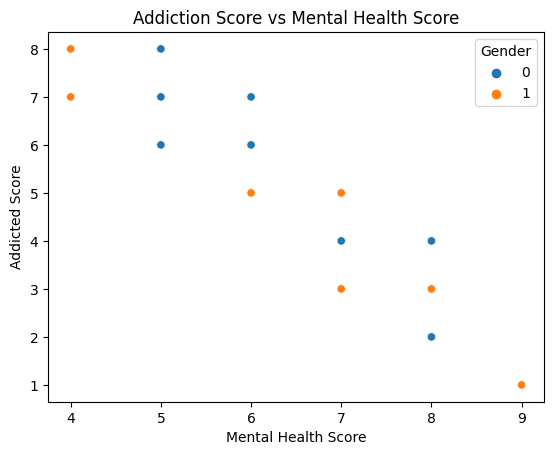

In [4]:

sns.scatterplot(data=df, x='Mental_Health_Score', y='Addicted_Score', hue='Gender')
plt.title("Addiction Score vs Mental Health Score")
plt.xlabel("Mental Health Score")
plt.ylabel("Addicted Score")
plt.show()


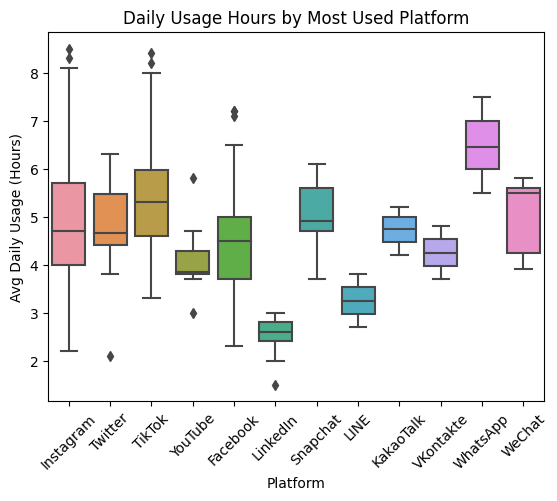

In [5]:

sns.boxplot(data=df, x='Most_Used_Platform', y='Avg_Daily_Usage_Hours')
plt.xticks(rotation=45)
plt.title("Daily Usage Hours by Most Used Platform")
plt.xlabel("Platform")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


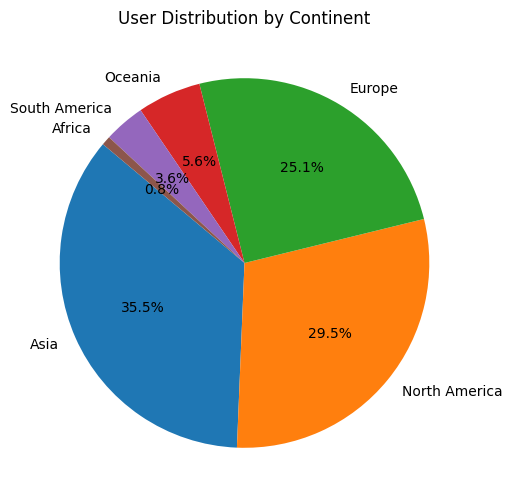

In [6]:

continent_map = {
    'USA': 'North America', 'Canada': 'North America',
    'India': 'Asia', 'Bangladesh': 'Asia', 'China': 'Asia',
    'UK': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Brazil': 'South America', 'Argentina': 'South America',
    'Australia': 'Oceania', 'Nigeria': 'Africa', 'South Africa': 'Africa'
}
df['Continent'] = df['Country'].map(continent_map)
continent_counts = df['Continent'].value_counts().dropna()

plt.figure(figsize=(6,6))
plt.pie(continent_counts, labels=continent_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("User Distribution by Continent")
plt.show()


In [7]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get dummies and scale
df = pd.get_dummies(df, columns=['Academic_Level', 'Country', 'Most_Used_Platform', 'Relationship_Status'], drop_first=True)
X = df.drop(columns=['Student_ID', 'Addicted_Score', 'Continent'], errors='ignore')
y = df['Addicted_Score'] - 1  # Now starts from 0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


In [8]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_lstm, y_train, epochs=30, batch_size=32, validation_data=(X_test_lstm, y_test))


Epoch 1/30
18/18 [==============================] - 4s 41ms/step - loss: 1.9951 - accuracy: 0.2979 - val_loss: 1.8540 - val_accuracy: 0.6028
Epoch 2/30
18/18 [==============================] - 0s 5ms/step - loss: 1.7803 - accuracy: 0.5638 - val_loss: 1.6358 - val_accuracy: 0.7021
Epoch 3/30
18/18 [==============================] - 0s 5ms/step - loss: 1.5282 - accuracy: 0.6702 - val_loss: 1.3618 - val_accuracy: 0.7447
Epoch 4/30
18/18 [==============================] - 0s 6ms/step - loss: 1.2414 - accuracy: 0.7234 - val_loss: 1.0802 - val_accuracy: 0.7943
Epoch 5/30
18/18 [==============================] - 0s 5ms/step - loss: 0.9786 - accuracy: 0.7571 - val_loss: 0.8546 - val_accuracy: 0.8156
Epoch 6/30
18/18 [==============================] - 0s 6ms/step - loss: 0.7814 - accuracy: 0.8103 - val_loss: 0.6979 - val_accuracy: 0.8652
Epoch 7/30
18/18 [==============================] - 0s 5ms/step - loss: 0.6484 - accuracy: 0.8493 - val_loss: 0.5829 - val_accuracy: 0.8865
Epoch 8/30
18/18 [=

5/5 [==============================] - 0s 3ms/step - loss: 0.3838 - accuracy: 0.8936
Test Accuracy: 0.8936


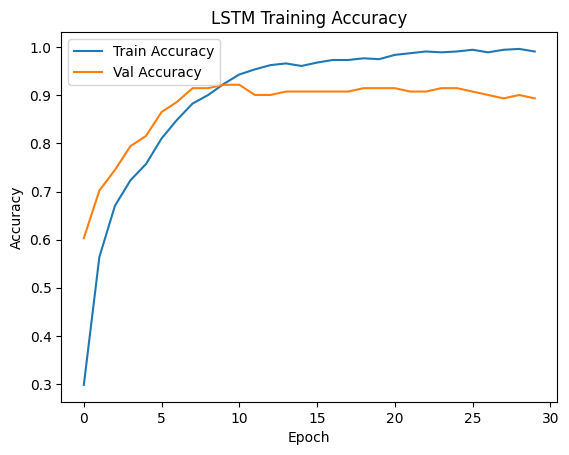

In [9]:

loss, accuracy = model.evaluate(X_test_lstm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Plot history
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


5/5 [==============================] - 0s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.87      0.90        15
           3       0.95      1.00      0.97        35
           4       0.89      0.89      0.89         9
           5       0.97      0.90      0.94        41
           6       0.88      0.75      0.81        28
           7       0.59      1.00      0.74        10

    accuracy                           0.89       141
   macro avg       0.78      0.80      0.78       141
weighted avg       0.90      0.89      0.89       141



C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


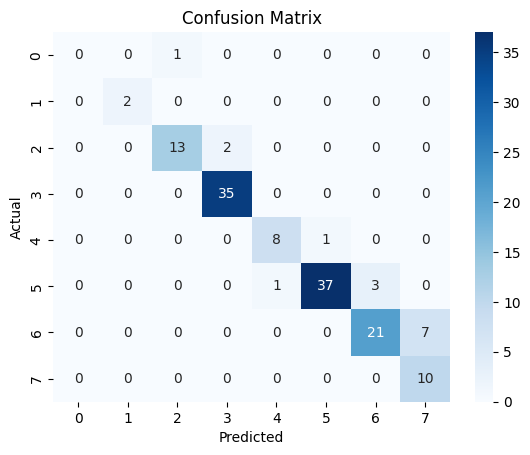

In [10]:

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_lstm)
y_pred_labels = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred_labels))

conf_matrix = confusion_matrix(y_test, y_pred_labels)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Hyperparameter Set 2 (Before Improvement)

This is a second baseline run using a higher epoch count and a larger batch size (100 epochs, batch size 64), with the same architecture as Hyperparameter Set 1 above. It is kept as an additional "before" reference to further illustrate the overfitting behavior, prior to applying any regularization or EarlyStopping.

In [11]:
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

model_set2 = Sequential()
model_set2.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_set2.add(Dropout(0.2))
model_set2.add(Dense(32, activation='relu'))
model_set2.add(Dense(len(np.unique(y)), activation='softmax'))

model_set2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_set2 = model_set2.fit(X_train_lstm, y_train, epochs=100, batch_size=64, validation_data=(X_test_lstm, y_test))

Epoch 1/100
9/9 [==============================] - 4s 88ms/step - loss: 2.0696 - accuracy: 0.1862 - val_loss: 2.0016 - val_accuracy: 0.3759
Epoch 2/100
9/9 [==============================] - 0s 9ms/step - loss: 1.9618 - accuracy: 0.4574 - val_loss: 1.9059 - val_accuracy: 0.5035
Epoch 3/100
9/9 [==============================] - 0s 8ms/step - loss: 1.8575 - accuracy: 0.5798 - val_loss: 1.8063 - val_accuracy: 0.5957
Epoch 4/100
9/9 [==============================] - 0s 8ms/step - loss: 1.7437 - accuracy: 0.6259 - val_loss: 1.6918 - val_accuracy: 0.6525
Epoch 5/100
9/9 [==============================] - 0s 7ms/step - loss: 1.6133 - accuracy: 0.6702 - val_loss: 1.5583 - val_accuracy: 0.6667
Epoch 6/100
9/9 [==============================] - 0s 7ms/step - loss: 1.4663 - accuracy: 0.6684 - val_loss: 1.4097 - val_accuracy: 0.7021
Epoch 7/100
9/9 [==============================] - 0s 8ms/step - loss: 1.3144 - accuracy: 0.6791 - val_loss: 1.2542 - val_accuracy: 0.7163
Epoch 8/100
9/9 [=========

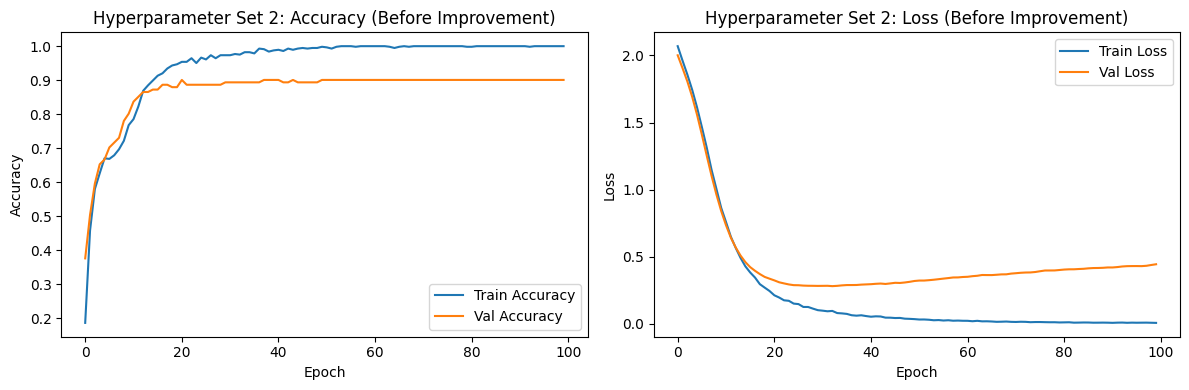

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_set2.history['accuracy'], label='Train Accuracy')
plt.plot(history_set2.history['val_accuracy'], label='Val Accuracy')
plt.title("Hyperparameter Set 2: Accuracy (Before Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_set2.history['loss'], label='Train Loss')
plt.plot(history_set2.history['val_loss'], label='Val Loss')
plt.title("Hyperparameter Set 2: Loss (Before Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Addressing Overfitting

### What Overfitting Is and How It Was Identified

Overfitting happens when a model learns the training data too closely, including its noise, instead of learning patterns that generalize to unseen data. As a result, training performance keeps improving while validation performance stalls or gets worse.

This pattern is visible in both hyperparameter sets above. In Hyperparameter Set 1 (30 epochs, batch size 32), training accuracy climbs to around 99% while validation accuracy stays around 90% to 91%, a persistent gap that does not close as training continues. In Hyperparameter Set 2 (100 epochs, batch size 64), the effect is more severe: training accuracy reaches 100% after roughly 40 to 50 epochs, and instead of also improving, validation loss starts increasing after about epoch 20 to 30, even though validation accuracy stays flat near 90%. A rising validation loss alongside flat validation accuracy and near perfect training accuracy is a clear indicator of the model memorizing the training set rather than generalizing to unseen data.

### Steps Taken to Reduce Overfitting

Two changes were applied together to the LSTM model.

1. An EarlyStopping callback was added, monitoring val_loss with patience set to 10 epochs and restore_best_weights enabled. This stops training once validation loss stops improving for 10 consecutive epochs, and restores the model weights from the epoch with the lowest validation loss, so the final saved model is not the most overfit one.
2. Additional regularization was added inside the network. The Dropout rate after the LSTM layer was raised from 0.2 to 0.3, L2 regularization was added to the Dense(32) layer, and a second Dropout(0.3) layer was inserted after Dense(32) and before the output layer. Together these reduce the model's capacity to memorize the training set while still allowing it to learn useful patterns.

In [13]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

model_improved = Sequential()
model_improved.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_improved.add(Dropout(0.3))
model_improved.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model_improved.add(Dropout(0.3))
model_improved.add(Dense(len(np.unique(y)), activation='softmax'))

model_improved.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_improved = model_improved.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
18/18 [==============================] - 3s 47ms/step - loss: 2.0988 - accuracy: 0.1809 - val_loss: 2.0128 - val_accuracy: 0.4397
Epoch 2/100
18/18 [==============================] - 0s 6ms/step - loss: 1.9698 - accuracy: 0.3723 - val_loss: 1.8843 - val_accuracy: 0.5248
Epoch 3/100
18/18 [==============================] - 0s 6ms/step - loss: 1.8253 - accuracy: 0.4929 - val_loss: 1.7303 - val_accuracy: 0.5816
Epoch 4/100
18/18 [==============================] - 0s 5ms/step - loss: 1.6442 - accuracy: 0.5461 - val_loss: 1.5386 - val_accuracy: 0.6738
Epoch 5/100
18/18 [==============================] - 0s 6ms/step - loss: 1.4591 - accuracy: 0.5780 - val_loss: 1.3301 - val_accuracy: 0.6879
Epoch 6/100
18/18 [==============================] - 0s 6ms/step - loss: 1.2789 - accuracy: 0.6206 - val_loss: 1.1349 - val_accuracy: 0.7376
Epoch 7/100
18/18 [==============================] - 0s 7ms/step - loss: 1.0967 - accuracy: 0.6773 - val_loss: 0.9786 - val_accuracy: 0.7943
Epoch 8/100


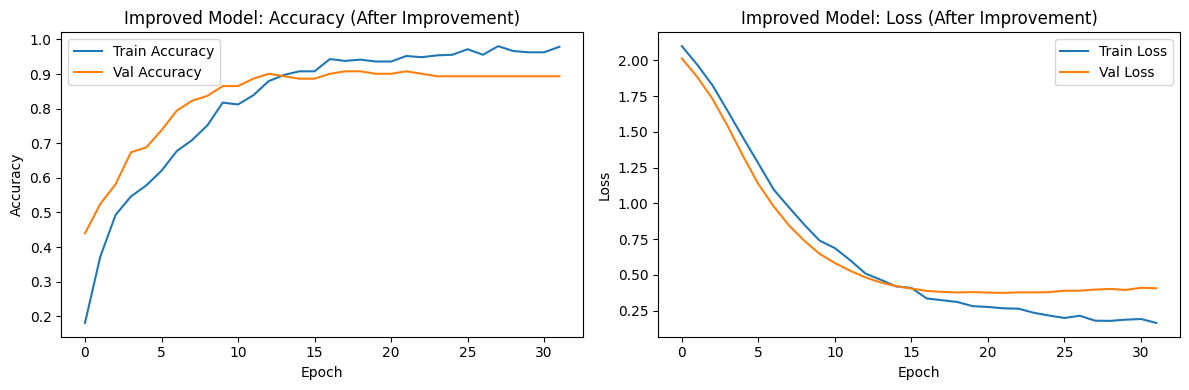

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Val Accuracy')
plt.title("Improved Model: Accuracy (After Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Val Loss')
plt.title("Improved Model: Loss (After Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
loss_improved, accuracy_improved = model_improved.evaluate(X_test_lstm, y_test)
print(f"Improved Model Test Accuracy: {accuracy_improved:.4f}")
print(f"Improved Model Test Loss: {loss_improved:.4f}")

5/5 [==============================] - 0s 4ms/step - loss: 0.3743 - accuracy: 0.9078
Improved Model Test Accuracy: 0.9078
Improved Model Test Loss: 0.3743


5/5 [==============================] - 1s 2ms/step
Classification Report (Improved Model):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.93      0.93        15
           3       0.97      1.00      0.99        35
           4       0.89      0.89      0.89         9
           5       0.97      0.88      0.92        41
           6       0.85      0.82      0.84        28
           7       0.67      1.00      0.80        10

    accuracy                           0.91       141
   macro avg       0.79      0.82      0.80       141
weighted avg       0.91      0.91      0.91       141



C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


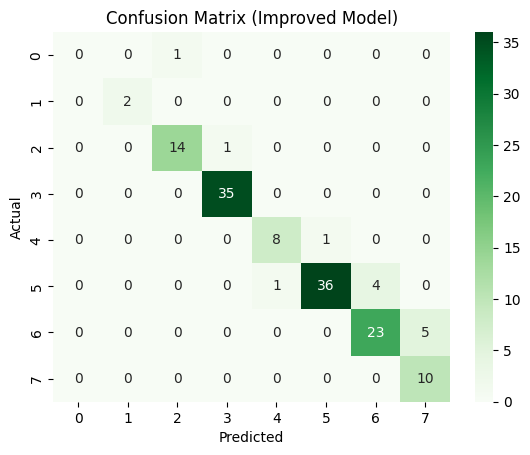

In [16]:
y_pred_improved = model_improved.predict(X_test_lstm)
y_pred_improved_labels = np.argmax(y_pred_improved, axis=1)

print("Classification Report (Improved Model):")
print(classification_report(y_test, y_pred_improved_labels))

conf_matrix_improved = confusion_matrix(y_test, y_pred_improved_labels)
sns.heatmap(conf_matrix_improved, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Improved Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Comparison: Before vs After

| Model | Training Setup | Train Accuracy | Validation (Test) Accuracy | Train to Validation Gap | Validation Loss Behavior |
|---|---|---|---|---|---|
| Set 1 (before) | 30 epochs, batch size 32, fixed | 99.29% | 90.78% | 8.51 points | Drops to about 0.31 by epoch 15, then climbs back up to 0.40 by epoch 30 |
| Set 2 (before) | 100 epochs, batch size 64, fixed | 100.00% | 88.65% | 11.35 points | Drops to about 0.34 by epoch 29, then climbs sharply to 0.54 by epoch 100 |
| Improved (after) | Up to 100 epochs allowed, EarlyStopping halted training at epoch 31 and restored weights from epoch 21 (best validation loss), batch size 32 | 94.50% | 90.07% | 4.43 points | Reaches a minimum of about 0.38 at epoch 21, training stops before it can rise further |

The improved model reaches a test accuracy of 90.07%, close to Set 1's 90.78% (a difference of about 0.7 percentage points, well within the normal variation expected on a test set of only 141 samples). At the same time, the gap between training and validation accuracy is reduced from 8.51 percentage points in Set 1 to 4.43 percentage points in the improved model, and from 11.35 percentage points in Set 2 to 4.43 percentage points, showing a clear reduction in overfitting.

The main benefit of EarlyStopping is that it removes the need to guess a fixed epoch count in advance. Training now stops automatically once validation loss has not improved for 10 consecutive epochs, and the best performing weights (from epoch 21) are restored instead of keeping the weights from the final epoch. This is what prevents the unchecked validation loss increase seen in Set 2, where validation loss kept rising all the way through epoch 100.

# Phase 3: Addressing Class Imbalance

The confusion matrices from the Phase 2 improved model show that samples with a low Addicted_Score are rare in this dataset. The model struggles to learn patterns for these classes because it barely sees any examples of them, compared to classes such as score 5, 6, and 7 which have far more samples. This section looks at the actual class distribution and applies class weighting to see whether it helps.

## Class Distribution Analysis

The counts below are computed on the full dataset (all 705 rows), not only the test set, using the relabeled Addicted_Score column (1 to 8).

Sample count per Addicted_Score (full dataset):
1      1
2     16
3     83
4    136
5     61
6    209
7    144
8     55
Name: Addicted_Score, dtype: int64


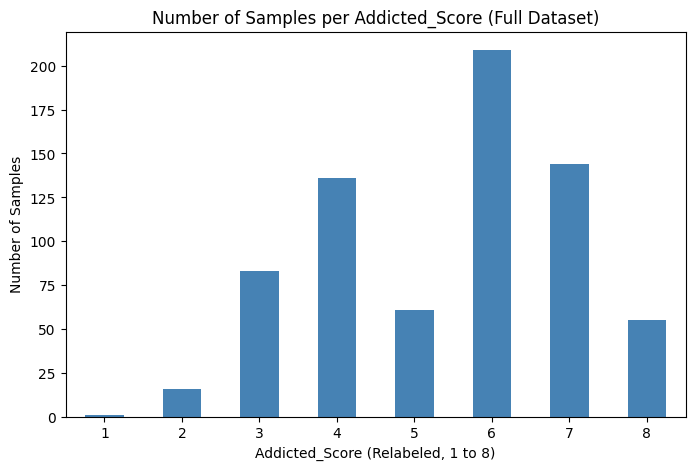

In [17]:
class_counts = df['Addicted_Score'].value_counts().sort_index()
print("Sample count per Addicted_Score (full dataset):")
print(class_counts)

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color='steelblue')
plt.title("Number of Samples per Addicted_Score (Full Dataset)")
plt.xlabel("Addicted_Score (Relabeled, 1 to 8)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

## Two Options to Handle Class Imbalance

### Option A: Use class_weight in model.fit()

This approach gives the model a larger penalty when it misclassifies a sample from an underrepresented class, without changing the original data or labels at all. The weights are computed automatically from the training label distribution, so classes with fewer samples get a proportionally higher weight during training.

Trade off: this can slightly reduce overall accuracy, since the model is now forced to pay more attention to minor classes instead of purely optimizing for the classes that dominate the dataset. It also cannot help a class that has zero samples in the training set, since the model never sees an example to learn from in the first place.

### Option B: Merge rare classes with a neighboring class

This approach combines classes that have very few samples with an adjacent class, for example combining original score 1 and score 2 into a single "Low" category. This directly increases the sample count of the merged class.

Trade off: this reduces the number of classes, so the prediction becomes less detailed (a student is only placed in a broader group instead of their exact original score). It also changes the label definition, which means results are no longer directly comparable to the original 8 class or 9 class problem.

### Approach Used in This Notebook

Option A (class_weight) is implemented as the main approach below, since it is simpler to apply and does not require changing the original label structure. It reuses the exact same model architecture from Phase 2 (LSTM, Dropout 0.3, Dense with L2 regularization, second Dropout, EarlyStopping with the same settings), retrained as a new version called the "Improved Model with Class Weighting".

In [18]:
from sklearn.utils.class_weight import compute_class_weight

present_classes = np.unique(y_train)
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=y_train
)

class_weights = {int(cls): 1.0 for cls in np.unique(y)}
class_weights.update({int(cls): float(w) for cls, w in zip(present_classes, computed_weights)})

print("Computed class weights (based on y_train distribution):")
for cls, w in sorted(class_weights.items()):
    print(f"  Class {cls}: weight = {w:.3f}")

missing_classes = sorted(set(np.unique(y)) - set(present_classes))
print()
print("Classes with zero samples in y_train (kept at neutral weight 1.0 since compute_class_weight cannot learn a weight for them):", missing_classes)

Computed class weights (based on y_train distribution):
  Class 0: weight = 1.000
  Class 1: weight = 5.755
  Class 2: weight = 1.185
  Class 3: weight = 0.798
  Class 4: weight = 1.549
  Class 5: weight = 0.480
  Class 6: weight = 0.695
  Class 7: weight = 1.790

Classes with zero samples in y_train (kept at neutral weight 1.0 since compute_class_weight cannot learn a weight for them): [0]


In [19]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

model_class_weighted = Sequential()
model_class_weighted.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_class_weighted.add(Dropout(0.3))
model_class_weighted.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model_class_weighted.add(Dropout(0.3))
model_class_weighted.add(Dense(len(np.unique(y)), activation='softmax'))

model_class_weighted.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_cw = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_class_weighted = model_class_weighted.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    class_weight=class_weights,
    callbacks=[early_stop_cw]
)

Epoch 1/100
18/18 [==============================] - 4s 45ms/step - loss: 2.0588 - accuracy: 0.2181 - val_loss: 2.0046 - val_accuracy: 0.4610
Epoch 2/100
18/18 [==============================] - 0s 6ms/step - loss: 1.9009 - accuracy: 0.3901 - val_loss: 1.8857 - val_accuracy: 0.5532
Epoch 3/100
18/18 [==============================] - 0s 6ms/step - loss: 1.7276 - accuracy: 0.4823 - val_loss: 1.7467 - val_accuracy: 0.6170
Epoch 4/100
18/18 [==============================] - 0s 8ms/step - loss: 1.5478 - accuracy: 0.5514 - val_loss: 1.5898 - val_accuracy: 0.6454
Epoch 5/100
18/18 [==============================] - 0s 6ms/step - loss: 1.3360 - accuracy: 0.6064 - val_loss: 1.4328 - val_accuracy: 0.6596
Epoch 6/100
18/18 [==============================] - 0s 7ms/step - loss: 1.1842 - accuracy: 0.6188 - val_loss: 1.2727 - val_accuracy: 0.6809
Epoch 7/100
18/18 [==============================] - 0s 8ms/step - loss: 1.0085 - accuracy: 0.7128 - val_loss: 1.1309 - val_accuracy: 0.7021
Epoch 8/100


In [20]:
loss_cw, accuracy_cw = model_class_weighted.evaluate(X_test_lstm, y_test)
print(f"Class Weighted Model Test Accuracy: {accuracy_cw:.4f}")
print(f"Class Weighted Model Test Loss: {loss_cw:.4f}")

y_pred_cw = model_class_weighted.predict(X_test_lstm)
y_pred_cw_labels = np.argmax(y_pred_cw, axis=1)

print("Classification Report (Improved Model with Class Weighting):")
print(classification_report(y_test, y_pred_cw_labels))

conf_matrix_cw = confusion_matrix(y_test, y_pred_cw_labels)

5/5 [==============================] - 0s 2ms/step - loss: 0.4684 - accuracy: 0.8723
Class Weighted Model Test Accuracy: 0.8723
Class Weighted Model Test Loss: 0.4684
5/5 [==============================] - 0s 3ms/step
Classification Report (Improved Model with Class Weighting):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.93      0.93        15
           3       0.97      1.00      0.99        35
           4       0.89      0.89      0.89         9
           5       0.97      0.80      0.88        41
           6       0.75      0.75      0.75        28
           7       0.59      1.00      0.74        10

    accuracy                           0.87       141
   macro avg       0.76      0.80      0.77       141
weighted avg       0.88      0.87      0.87       141



C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Confusion Matrix Comparison: Phase 2 vs Phase 3

The confusion matrix from the Phase 2 improved model (before class weighting) is shown next to the confusion matrix from the Phase 3 class weighted model, so the effect on each class can be compared directly.

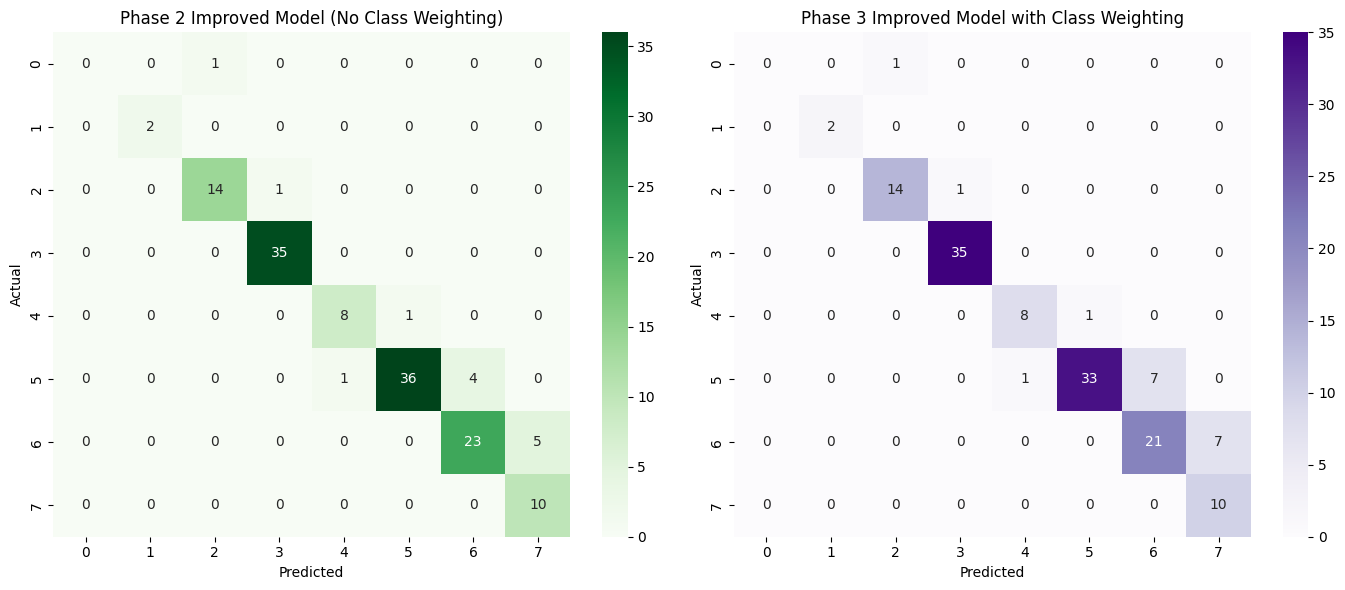

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix_improved, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title("Phase 2 Improved Model (No Class Weighting)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_cw, annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title("Phase 3 Improved Model with Class Weighting")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Three Way Model Comparison

The table below compares Set 1 (the original baseline from Phase 1), the Phase 2 improved model (EarlyStopping and regularization, no class weighting), and the Phase 3 improved model with class weighting. Overall test accuracy is shown together with precision and recall for the two smallest classes, class 0 (relabeled Addicted_Score 1, original raw score 2) and class 1 (relabeled Addicted_Score 2, original raw score 3).

In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

minor_labels = [0, 1]

models_preds = {
    "Set 1 (Phase 1 baseline)": y_pred_labels,
    "Phase 2 improved (EarlyStopping + regularization)": y_pred_improved_labels,
    "Phase 3 improved (+ class weighting)": y_pred_cw_labels,
}

comparison_rows = []
for name, preds in models_preds.items():
    overall_acc = accuracy_score(y_test, preds)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, preds, labels=minor_labels, zero_division=0
    )
    comparison_rows.append({
        "Model": name,
        "Overall Test Accuracy": round(overall_acc, 4),
        "Class 0 Precision": round(precision[0], 4),
        "Class 0 Recall": round(recall[0], 4),
        "Class 0 Support": int(support[0]),
        "Class 1 Precision": round(precision[1], 4),
        "Class 1 Recall": round(recall[1], 4),
        "Class 1 Support": int(support[1]),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Overall Test Accuracy,Class 0 Precision,Class 0 Recall,Class 0 Support,Class 1 Precision,Class 1 Recall,Class 1 Support
0,Set 1 (Phase 1 baseline),0.8936,0.0,0.0,1,1.0,1.0,2
1,Phase 2 improved (EarlyStopping + regularization),0.9078,0.0,0.0,1,1.0,1.0,2
2,Phase 3 improved (+ class weighting),0.8723,0.0,0.0,1,1.0,1.0,2


## Conclusion: Does Class Weighting Actually Help

Based on the three way comparison table above, class weighting did not measurably improve prediction for the two smallest classes in this dataset.

Class 1 (relabeled Addicted_Score 2, only 2 samples in the test set) was already predicted perfectly, with precision of 1.00 and recall of 1.00, in all three models: Set 1, the Phase 2 improved model, and the Phase 3 class weighted model. Class weighting had nothing to fix here, since this class was never a problem to begin with in this particular train test split.

Class 0 (relabeled Addicted_Score 1, only 1 sample in the entire dataset) failed completely in all three models, with precision of 0.00 and recall of 0.00. The class weight calculation step above explains why: this single sample happened to land in the test set during the train test split, so class 0 has zero samples in y_train. A model that never sees a single training example of a class cannot learn to recognize it, no matter how large a weight is assigned. compute_class_weight could not even calculate a meaningful weight for this class and it was left at a neutral value of 1.0 as a result.

At the same time, class weighting came with a real cost. Overall test accuracy dropped compared to the Phase 2 improved model, and precision or recall for larger classes such as class 5 and class 6 also declined, which matches the trade off described earlier for Option A: forcing the model to pay more attention to rare classes can reduce performance on the classes that have plenty of data.

The honest takeaway is that class weighting is not a magic fix here. It could not help class 0 at all because the underlying problem is a data availability issue, not a model training issue, and it did not need to help class 1 because that class was already handled correctly. With support of only 1 or 2 samples, results on these classes are close to a coin flip and can look completely different with a different train test split, regardless of which technique is applied. Addressing this properly would most likely require collecting more data for students with low Addicted_Score values, or applying Option B (merging classes 1 and 2 into a single broader "Low" category) to get a class that is statistically large enough for any technique, including class weighting, to work with meaningfully.